# 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Verimizin kolon anlamlari 
1-PassangerId -> yolcularin id 
2-Survived -> 0'oldu' & 1'yasadi'
3-Pclass -> 1'zengin' & 2'orta' & 3'ekonomik'
4-Name -> yolcunun adi , soyadi ,unavani
5-Sex -> cinsiyet
6-Age -> yas
7-SibSp -> yolcularin gemide bulunan kardes ve es sayilari 
8-Parch -> yolcularin anne-babasi ve cocuklarinin sayisi
9-Ticket -> bilet numarisi
10-Fare -> yolcunun bilet icin odedigi ucret 
11-Cabin -> yolcunun kaldigi kabin numarasi
12-Embarked -> yolcunun titanice hangi limandan bindigi 

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# Cbin kolonumuzda 687 tane bosluk oldugu icin bu kolanu silmeyi daha uygun goruyorum cunku bosluk yuzde %77 

In [7]:
df.drop('Cabin',axis=1,inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [9]:
# yas kiminda 177 tane bosluk var kolonu silmek cok mantiksiz olur name kisminda unvana gore yas atamasi yapip vermi dolduracam 

In [10]:
# buradan unavalar la yeni bir kolon olsuturacam

In [11]:
df['Unvan'] = df['Name'].str.extract('([A-Za-z]+)\.',expand=False)

In [12]:
df['Unvan'].value_counts()

Unvan
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [13]:
# arastirma yaptigimiz mlle fransizda inglizcede ki miss ile ayni anlama gelmektedir , Ms de evlelik drumununun belirtilmedigi zamandan kullaniliyor
# bundan dolayi bu ikisini miss e dahil edcegim ve digerlerinie baska bir kolonda birlestirip daha kisa bir tablo elde edecem

In [14]:
df['Unvan'] = df['Unvan'].replace(['Mlle','Ms'],'Miss')
donusum = ['Master','Dr','Rev','Col','Major','Mme','Don','Lady','Sir','Capt','Countess','Jonkheer']
df['Unvan'] = df['Unvan'].replace(donusum,'Other')

In [15]:
df['Unvan'].value_counts()

Unvan
Mr       517
Miss     185
Mrs      125
Other     64
Name: count, dtype: int64

In [16]:
# daha sade bir veri var elimizde artik age bosluklarini burdaki kolonlarin ortlaamasina gore doldurabiliriz

In [17]:
df['Age'] = df.groupby('Unvan')['Age'].transform(lambda x: x.fillna(x.mean()))

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
Unvan          0
dtype: int64

In [19]:
# goruldugu uzere age kolonumuzda en iyi sekilde doldurmus oldum geri embarked kaldi bos veri 2 tane oldugu icin bu 2 tanesini direk silecem

In [20]:
df.dropna(subset=['Embarked'],inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
 11  Unvan        889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [22]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Unvan          0
dtype: int64

In [23]:
# vermizdeki bos veri kismini halletik simdi sirada dtype kismini kontrol etmekte 

In [24]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Unvan           object
dtype: object

In [25]:
# unvan adi altinda yeni bir kolon olustudum bundan dolayi name kolonunu siliyorum isim bilmek isime yaramaz

In [26]:
df.drop('Name',axis=1,inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    object 
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Ticket       889 non-null    object 
 8   Fare         889 non-null    float64
 9   Embarked     889 non-null    object 
 10  Unvan        889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [28]:
df['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
CA 2144            6
347088             6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
7546               1
Name: count, Length: 680, dtype: int64

In [29]:
# 680 tane farkli vermi var elimizde herhangi bir analiz yapamam bundan dolayi ticket kolonumuzuda siliyorum

In [30]:
df.drop('Ticket',axis=1,inplace=True)

In [31]:
# Sex kismini 0 ve 1 olucak sekilde degistirmek istiyorum

In [32]:
df['Sex'].value_counts()

Sex
male      577
female    312
Name: count, dtype: int64

In [33]:
df['Sex'] = df['Sex'].replace('male',0)
df['Sex'] = df['Sex'].replace('female',1)

C:\Users\PC\AppData\Local\Temp\ipykernel_16704\772191369.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace('female',1)


In [34]:
df['Sex'].value_counts()

Sex
0    577
1    312
Name: count, dtype: int64

In [35]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [36]:
df['Embarked_S'] = 0
df['Embarked_C'] = 0
df['Embarked_Q'] = 0

df.loc[df['Embarked'] == 'S','Embarked_S'] = 1 
df.loc[df['Embarked'] == 'C','Embarked_C'] = 1 
df.loc[df['Embarked'] == 'Q','Embarked_Q'] = 1 

In [37]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Unvan,Embarked_S,Embarked_C,Embarked_Q
0,1,0,3,0,22.0,1,0,7.2500,S,Mr,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,C,Mrs,0,1,0
2,3,1,3,1,26.0,0,0,7.9250,S,Miss,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,S,Mrs,1,0,0
4,5,0,3,0,35.0,0,0,8.0500,S,Mr,1,0,0


In [38]:
# artik vermizde embarked kolonuna gerek kalmadi cunku yeni olsuturdugumuz kolonlarla beraber kisinin nerden bindigini gorebiliyoruz

In [39]:
df.drop('Embarked',axis=1,inplace=True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    int64  
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Unvan        889 non-null    object 
 9   Embarked_S   889 non-null    int64  
 10  Embarked_C   889 non-null    int64  
 11  Embarked_Q   889 non-null    int64  
dtypes: float64(2), int64(9), object(1)
memory usage: 90.3+ KB


In [41]:
# vermizde artik sadece Unvan object kaldi onu duzletip ver temizleme duzenleme islemini bitirecem

In [42]:
df['Unvan'].value_counts()

Unvan
Mr       517
Miss     184
Mrs      124
Other     64
Name: count, dtype: int64

In [43]:
df['Unvan_Mr'] = 0 
df['Unvan_Miss'] = 0 
df['Unvan_Mrs'] = 0 
df['Unvan_Other'] = 0 

df.loc[df['Unvan'] == 'Mr','Unvan_Mr'] = 1
df.loc[df['Unvan'] == 'Miss','Unvan_Miss'] = 1
df.loc[df['Unvan'] == 'Mrs','Unvan_Mrs'] = 1
df.loc[df['Unvan'] == 'Other','Unvan_Other'] = 1

In [44]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Unvan,Embarked_S,Embarked_C,Embarked_Q,Unvan_Mr,Unvan_Miss,Unvan_Mrs,Unvan_Other
0,1,0,3,0,22.0,1,0,7.2500,Mr,1,0,0,1,0,0,0
1,2,1,1,1,38.0,1,0,71.2833,Mrs,0,1,0,0,0,1,0
2,3,1,3,1,26.0,0,0,7.9250,Miss,1,0,0,0,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,Mrs,1,0,0,0,0,1,0
4,5,0,3,0,35.0,0,0,8.0500,Mr,1,0,0,1,0,0,0


In [45]:
# artik unvan sutunumuzda gerek kalmadi onuda silince en iyi yalin temiz vermizi elde etmis olucaz

In [46]:
df.drop('Unvan',axis=1,inplace=True)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    int64  
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked_S   889 non-null    int64  
 9   Embarked_C   889 non-null    int64  
 10  Embarked_Q   889 non-null    int64  
 11  Unvan_Mr     889 non-null    int64  
 12  Unvan_Miss   889 non-null    int64  
 13  Unvan_Mrs    889 non-null    int64  
 14  Unvan_Other  889 non-null    int64  
dtypes: float64(2), int64(13)
memory usage: 111.1 KB


In [48]:
# EDA 

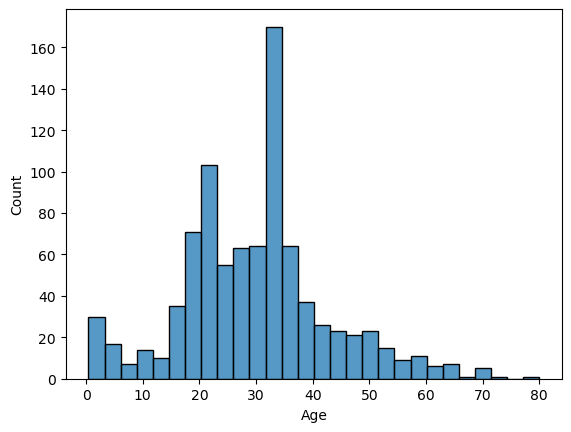

In [49]:
sns.histplot(data = df['Age'])
plt.show()

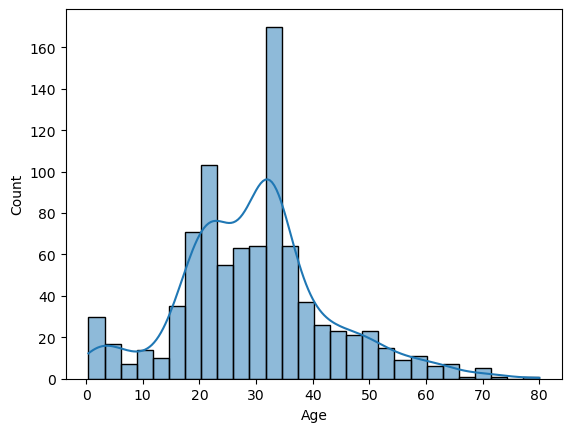

In [50]:
sns.histplot(data=df['Age'],kde=True)
plt.show()

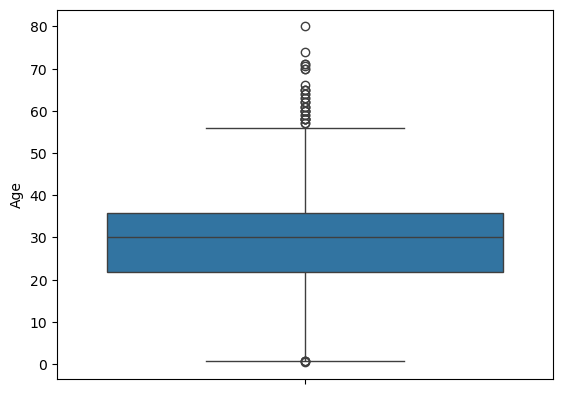

In [51]:
sns.boxplot(data=df,y='Age')
plt.show()

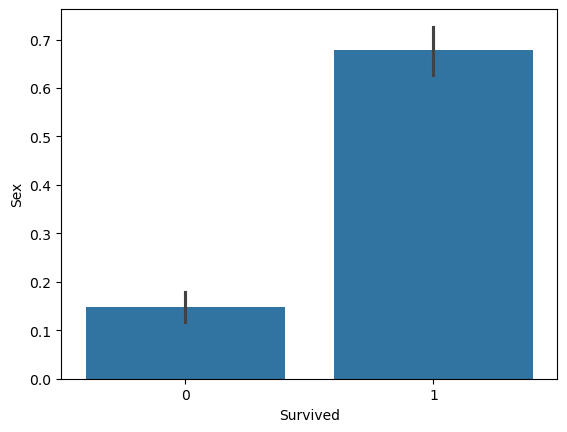

In [52]:
sns.barplot(x='Survived',y='Sex',data=df)
plt.show()

In [53]:
# verimizde sadece yasayan kadilnar oldugu icin boyle bir tablo cikti karsimiza

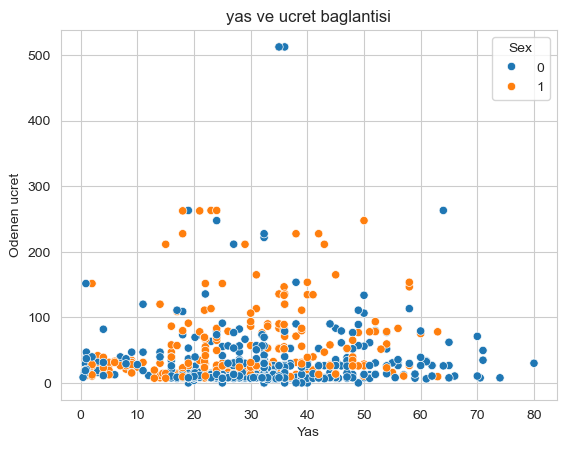

In [54]:
sns.set_style('whitegrid')
sns.scatterplot(x='Age',y='Fare',hue='Sex',data=df)
plt.xlabel('Yas')
plt.ylabel('Odenen ucret')
plt.title('yas ve ucret baglantisi')
plt.show()

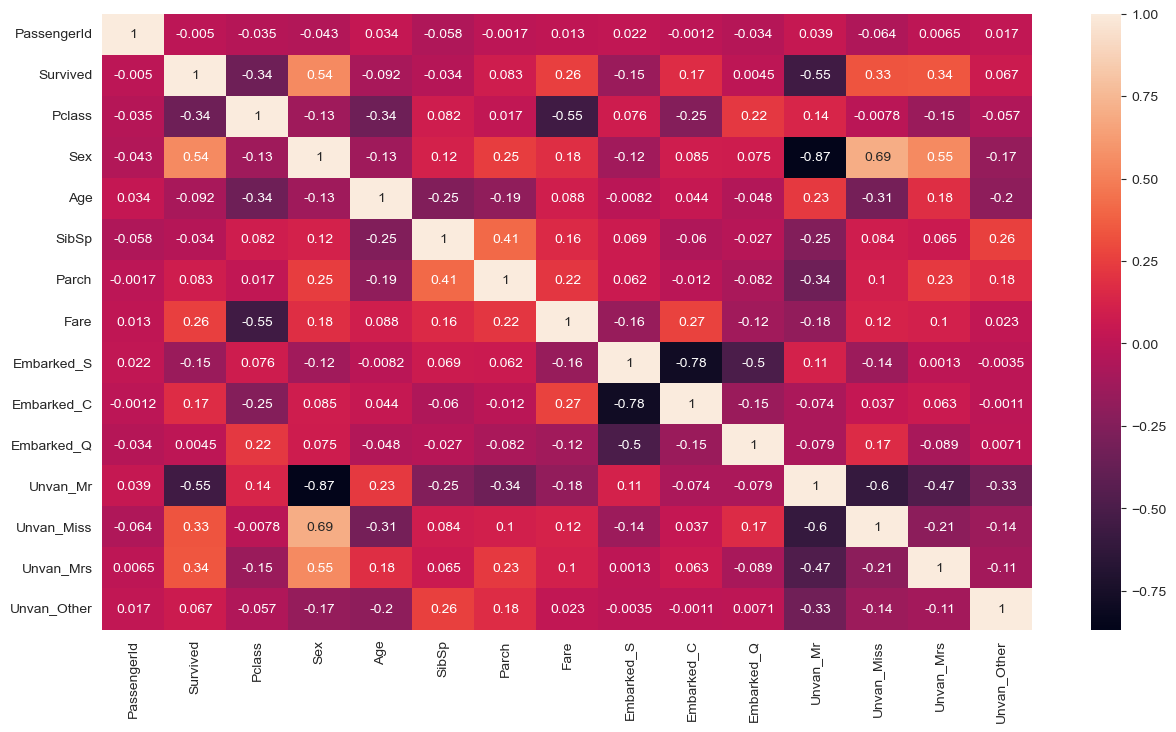

In [55]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

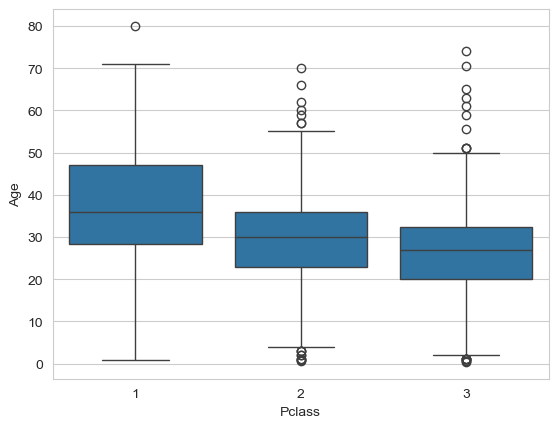

In [56]:
sns.boxplot(x='Pclass',y='Age',data=df)
plt.show()

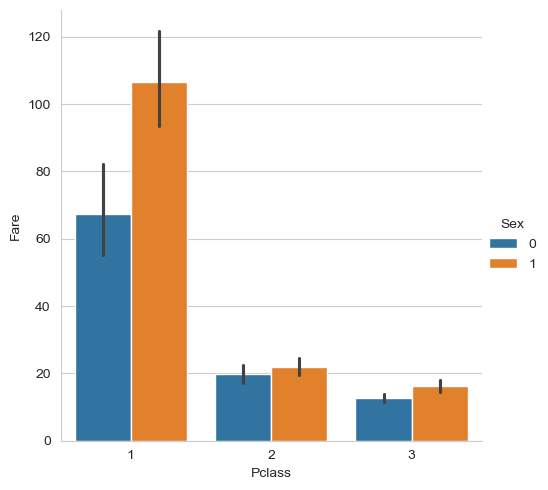

In [57]:
sns.catplot(x='Pclass',y='Fare',hue='Sex',kind='bar',data=df)
plt.show()

In [58]:
# Modelimizi egitmeye basliyoruz

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Sex          889 non-null    int64  
 4   Age          889 non-null    float64
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Fare         889 non-null    float64
 8   Embarked_S   889 non-null    int64  
 9   Embarked_C   889 non-null    int64  
 10  Embarked_Q   889 non-null    int64  
 11  Unvan_Mr     889 non-null    int64  
 12  Unvan_Miss   889 non-null    int64  
 13  Unvan_Mrs    889 non-null    int64  
 14  Unvan_Other  889 non-null    int64  
dtypes: float64(2), int64(13)
memory usage: 111.1 KB


In [60]:
X = df.drop(['Survived','PassengerId'],axis=1)
y = df['Survived']

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [63]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_S,Embarked_C,Embarked_Q,Unvan_Mr,Unvan_Miss,Unvan_Mrs,Unvan_Other
523,1,1,44.0,0,1,57.9792,0,1,0,0,0,1,0
225,3,0,22.0,0,0,9.3500,1,0,0,1,0,0,0
638,3,1,41.0,0,5,39.6875,1,0,0,0,0,1,0
259,2,1,50.0,0,1,26.0000,1,0,0,0,0,1,0
92,1,0,46.0,1,0,61.1750,1,0,0,1,0,0,0


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()

In [66]:
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [67]:
X_train_scaler

array([[-1.54570869,  1.33664164,  1.05872787, ..., -0.51590667,
         2.43669859, -0.26919095],
       [ 0.83725887, -0.74814368, -0.60248622, ..., -0.51590667,
        -0.41039134, -0.26919095],
       [ 0.83725887,  1.33664164,  0.83219868, ..., -0.51590667,
         2.43669859, -0.26919095],
       ...,
       [ 0.83725887, -0.74814368, -0.82901541, ..., -0.51590667,
        -0.41039134, -0.26919095],
       [ 0.83725887, -0.74814368,  0.30363056, ..., -0.51590667,
        -0.41039134, -0.26919095],
       [-1.54570869,  1.33664164,  0.44695922, ..., -0.51590667,
         2.43669859, -0.26919095]])

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
regression = LinearRegression()

In [70]:
regression.fit(X_train_scaler,y_train)

LinearRegression()

In [71]:
X_test_scaler[0]

array([ 0.83725887, -0.74814368,  1.05872787, -0.4643045 , -0.46897741,
       -0.49361907,  0.63179084, -0.48540861, -0.32322997,  0.85432437,
       -0.51590667, -0.41039134, -0.26919095])

In [72]:
df.iloc[0]

PassengerId     1.00
Survived        0.00
Pclass          3.00
Sex             0.00
Age            22.00
SibSp           1.00
Parch           0.00
Fare            7.25
Embarked_S      1.00
Embarked_C      0.00
Embarked_Q      0.00
Unvan_Mr        1.00
Unvan_Miss      0.00
Unvan_Mrs       0.00
Unvan_Other     0.00
Name: 0, dtype: float64

In [73]:
y_pred = regression.predict(X_test_scaler)

In [74]:
y_pred

array([ 0.02183027,  0.63032723,  0.10872625,  0.42002001, -0.11675376,
        0.39930841,  0.22131686,  0.12736827,  1.01935636,  0.12268198,
        0.10934558,  0.0169694 , -0.10697008,  0.69627848,  0.03152986,
        0.07536129,  0.30322155,  0.05256824,  0.0499793 ,  0.66432663,
        0.19085622, -0.08148077,  0.12360903,  0.07708169,  0.00322902,
        0.28526911,  0.08409714,  0.17364081,  0.85190294,  0.66973183,
        0.20355326,  0.6669642 ,  0.02520217,  0.12403874,  0.56939156,
        0.0748606 ,  0.60995114,  0.08048145,  0.74094603,  0.57258116,
        0.43425143,  0.39930841,  0.07548083,  0.1088449 ,  0.03695064,
        0.65179717,  0.27219187,  0.73373739, -0.04015321,  0.22508097,
        0.64997841,  0.67036934,  0.12268198,  0.1974068 ,  0.29669381,
        0.71161861,  0.21438174,  0.707847  ,  0.10322405,  0.57789359,
        0.08157776,  0.93022398,  0.1358588 ,  0.19485499,  0.09389545,
        1.05734665,  0.50339575,  0.65120152,  0.16050792,  0.21

In [75]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [76]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print('mse',mse)
print('mae',mae)
print('r2_score',r2)

mse 0.14511219769000602
mae 0.29228413393606223
r2_score 0.3925686465550242


In [77]:
# r2 scorumuz cok dusuk cikti zaten vermizi bu degerlerine bakmamiz sacmadir cunku bu veriler 0 ve 1 ler icin daha uygudnudr simdi daha 
# iyi sonuc elde edecegimiz kisma yonlenecegiz 

In [78]:
from sklearn.preprocessing import PolynomialFeatures

In [79]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [80]:
X_train_poly = poly.fit_transform(X_train_scaler)
X_test_poly = poly.transform(X_test_scaler)

In [81]:
X_train_poly

array([[ 1.        , -1.54570869,  1.33664164, ...,  5.9375    ,
        -0.65593721,  0.07246377],
       [ 1.        ,  0.83725887, -0.74814368, ...,  0.16842105,
         0.11047364,  0.07246377],
       [ 1.        ,  0.83725887,  1.33664164, ...,  5.9375    ,
        -0.65593721,  0.07246377],
       ...,
       [ 1.        ,  0.83725887, -0.74814368, ...,  0.16842105,
         0.11047364,  0.07246377],
       [ 1.        ,  0.83725887, -0.74814368, ...,  0.16842105,
         0.11047364,  0.07246377],
       [ 1.        , -1.54570869,  1.33664164, ...,  5.9375    ,
        -0.65593721,  0.07246377]])

In [82]:
regression = LinearRegression()
regression.fit(X_train_poly,y_train)

LinearRegression()

In [83]:
y_pred = regression.predict(X_test_poly)

In [84]:
from sklearn.metrics import r2_score,mean_squared_error

In [85]:
r2_score(y_test,y_pred)

0.29339201404701887

In [86]:
# R2 skorumuz burada daha da düştü. Çünkü polinom regresyon modeli aşırı karmaşıklaştırarak ezberletti (overfitting).
# Bu yöntemin de doğru olmadığını gördük. Şimdi bu katsayıları dizginlemek ve aşırı uyumu engellemek için Ridge, Lasso ve ElasticNet adımlarına geçiyoruz.

In [87]:
# LINEARREGRESSION MODEL 

mae 0.29228413393606223
mse 0.14511219769000602
r2 score 0.3925686465550242


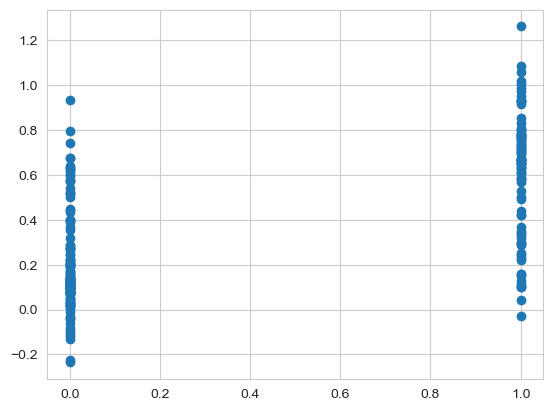

In [88]:
linear = LinearRegression()
linear.fit(X_train_scaler,y_train)
y_pred = linear.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [89]:
# linear regression modelini surekli sayilarda tahmin etm,ek icin kullnariiz ama bizde olmus yada yasiyor seklide yani 0 yada 1 
# bunda dolayi grafigimiz bu sekilide oldu

In [90]:
# LASSO 

mae 0.47436674342503937
mse 0.23915856227091223
score -0.0011040524554037923


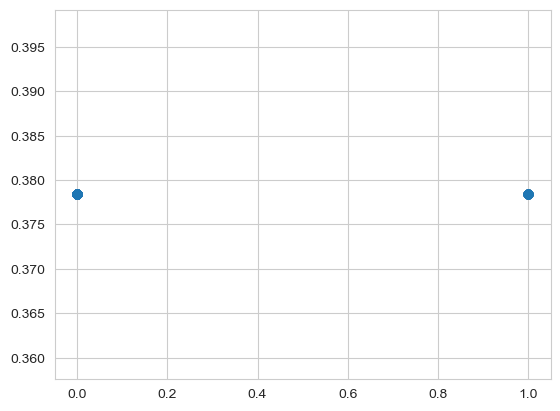

In [91]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaler,y_train)
y_pred = lasso.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [92]:
# cezalarin hepsini sifira zorladigi icin hicbir ise yaramadi lasso

In [93]:
# RIDGE 

mae 0.2922455872232969
mse 0.1451140953182682
r2 score 0.3925607031917373


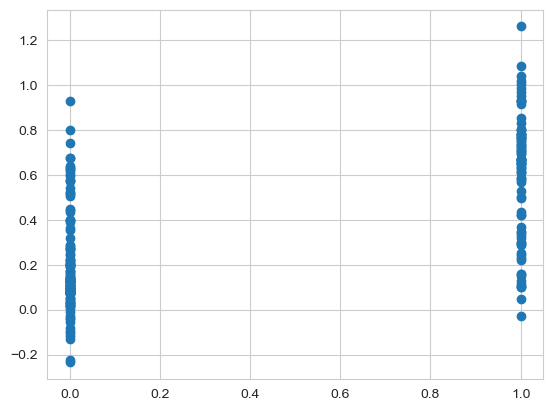

In [94]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaler,y_train)
y_pred = ridge.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()


In [95]:
# ridge sayilarimizi sifirlamak yerine busufer kucultu buda hicbir seyi degistermedi ve en bastaki garfigimizin aynisi oldu 

In [96]:
# ELASTICNET 

In [97]:
from sklearn.linear_model import ElasticNet

mae 0.47436674342503937
mse 0.23915856227091223
r2 score -0.0011040524554037923


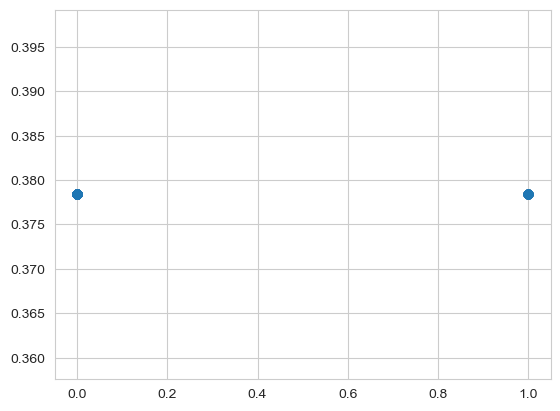

In [98]:
elastic = ElasticNet()
elastic.fit(X_train_scaler,y_train)
y_pred = elastic.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [99]:
# elastic ne zaten ridge ve  lasssonun birlestirilmis haliydi iyi bir veri cikmasi beklenemez 

In [100]:
# LassoCV 

In [101]:
from sklearn.linear_model import LassoCV

mse 0.14511418306757884
mae 0.2922754248301387
r2 score 0.39256033587814554


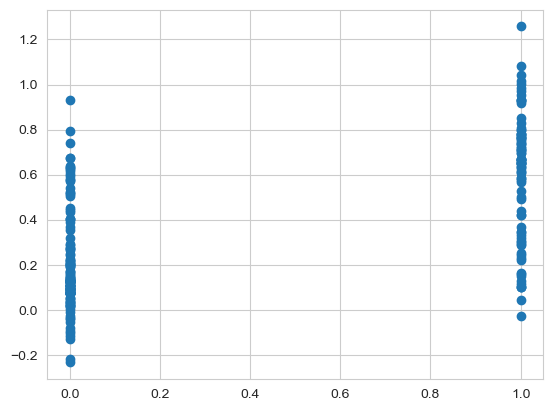

In [102]:
lassocv = LassoCV()
lassocv.fit(X_train_scaler,y_train)
y_pred = lassocv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mse',mse)
print('mae',mae)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [103]:
# RidgeCV 

In [106]:
from sklearn.linear_model import RidgeCV

mae 0.29262134264792616
mse 0.14518480059064834
r2 score 0.3922647349686572


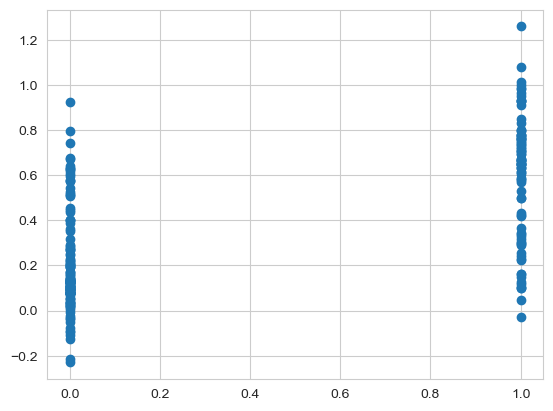

In [107]:
ridgecv = RidgeCV()
ridgecv.fit(X_train_scaler,y_train)
y_pred = ridgecv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('r2 score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [108]:
# ElasticnetCV 

In [109]:
from sklearn.linear_model import ElasticNetCV

mae 0.2922747861725281
mse 0.14511480408964542
score 0.39255773631532165


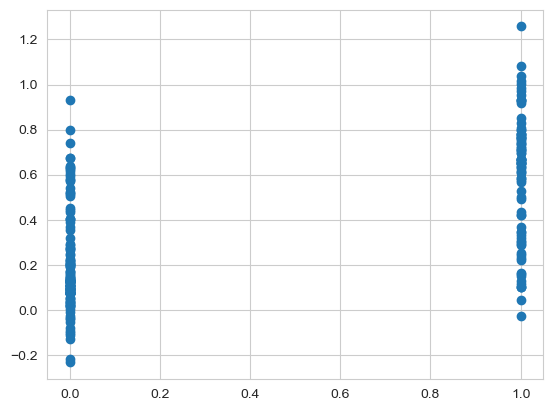

In [111]:
elasticnetcv = ElasticNetCV()
elasticnetcv.fit(X_train_scaler,y_train)
y_pred = elasticnetcv.predict(X_test_scaler)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print('mae',mae)
print('mse',mse)
print('score',score)
plt.scatter(y_test,y_pred)
plt.show()

In [112]:
# bunlari sadece gostermek icin yaptim vermizde ise yaramdiginfi biliyorduk sadeece gormek icin yaptim 

In [119]:
# aretik vermi tam olarak yapmak istiyorum  

In [114]:
from sklearn.linear_model import LogisticRegression

In [117]:
logistic = LogisticRegression()
logistic.fit(X_train_scaler,y_train)
y_pred = logistic.predict(X_test_scaler)

In [118]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0])

In [120]:
# olen ve olmeyenleri goruyoruz suanda

In [121]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [122]:
score = accuracy_score(y_test,y_pred)
print('score',score)
print(classification_report(y_test,y_pred))
print('confusion metrix ',confusion_matrix(y_test,y_pred))

score 0.8026905829596412
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       135
           1       0.78      0.70      0.74        88

    accuracy                           0.80       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223

confusion metrix  [[117  18]
 [ 26  62]]


In [123]:
# yuzde 80 civarinda yolcuunun hayasti hakkinda bilgiyi dogru bir sekilde tahmin etmisiz fena degil 
# oluleri daha iyi bir sekilde tahmin etmisiz 

In [124]:
# vermizin oranini daha yukari cekmek icin hyperparametre tuning yapmak istiyorum 

In [150]:
model = LogisticRegression()
penalty = ['l1','l2','elasticnet']
c_values = [100,10,1,0.1,0.01]
solver = ['newton-cg','lbfgs','liblinear','sag','saga','newton-cholesky']

In [151]:
params = dict(penalty=penalty,C=c_values,solver=solver)

In [152]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1, 0.1, 0.01],
 'solver': ['newton-cg',
  'lbfgs',
  'liblinear',
  'sag',
  'saga',
  'newton-cholesky']}

In [159]:
# Grid Search

In [160]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [161]:
cv = StratifiedKFold()

In [162]:
grid = GridSearchCV(estimator=model,param_grid=params,cv=cv,scoring='accuracy',n_jobs=-1)

In [163]:
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [164]:
grid.fit(X_train,y_train)

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
250 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solv

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1, 0.1, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga', 'newton-cholesky']},
             scoring='accuracy')

In [139]:
grid.best_params_

{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

In [140]:
grid.best_score_

np.float64(0.8243407025025251)

In [143]:
y_pred = grid.predict(X_test)

In [144]:
score = accuracy_score(y_test,y_pred)
print('score',score)
print(classification_report(y_test,y_pred))
print('confusion matrix',confusion_matrix(y_test,y_pred))

score 0.8026905829596412
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       135
           1       0.78      0.70      0.74        88

    accuracy                           0.80       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223

confusion matrix [[117  18]
 [ 26  62]]


In [145]:
# Decision TREE 

In [147]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import  Pipeline

In [165]:
numerical_cols = ['Age', 'Fare']
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numerical_cols)
    ], 
    remainder='passthrough')
X_train_transformation = preprocessor.fit_transform(X_train)
X_test_transformation = preprocessor.transform(X_test)

In [166]:
pd.DataFrame(X_train_transformation)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.058728,0.490447,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.602486,-0.467997,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.832199,0.129932,3.0,1.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.511786,-0.139838,2.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.209747,0.553434,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,0.001592,-0.493619,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
662,-0.904525,0.796350,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
663,-0.829015,-0.496658,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
664,0.303631,-0.493619,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [167]:
pd.DataFrame(X_test_transformation)[4].unique()

array([0., 3., 1., 8., 2., 4., 5.])

In [168]:
from sklearn.tree import DecisionTreeClassifier

In [169]:
tree_model = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
tree_model.fit(X_train_transformation,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [170]:
y_pred = tree_model.predict(X_test_transformation)

In [171]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       135
           1       0.78      0.73      0.75        88

    accuracy                           0.81       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223

[[117  18]
 [ 24  64]]
0.8116591928251121


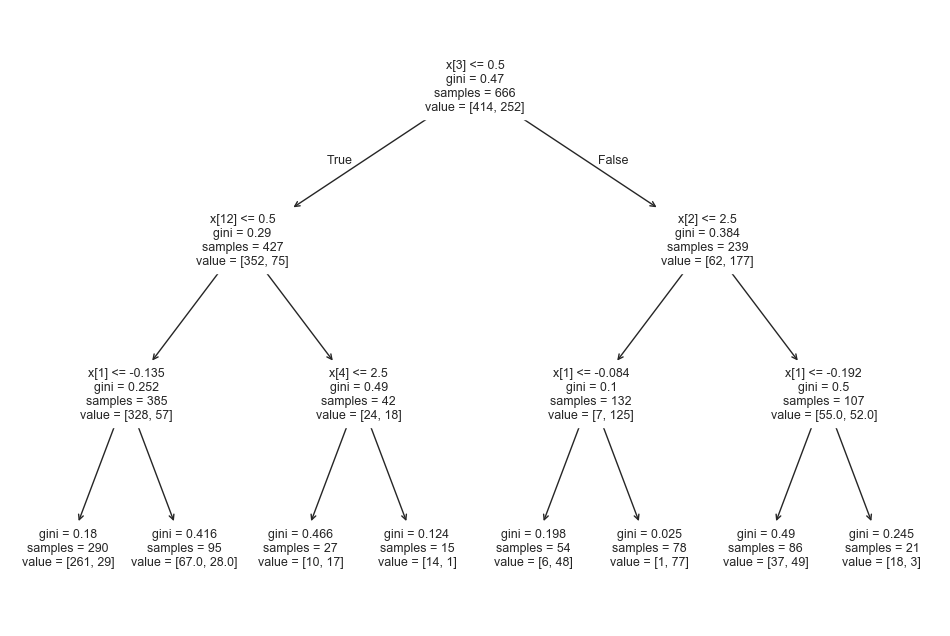

In [172]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(tree_model.fit(X_train_transformation,y_train))
plt.show()